In [33]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.datasets import load_diabetes

In [34]:
diabetes = load_diabetes()
df = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
df['target'] = diabetes.target

In [35]:
df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [36]:
df.describe()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
count,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,442.000000
mean,-2.511817e-19,1.230790e-17,-2.245564e-16,-4.797570e-17,-1.381499e-17,3.918434e-17,-5.777179e-18,-9.042540e-18,9.268604e-17,1.130318e-17,152.133484
std,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,77.093005
min,-1.072256e-01,-4.464164e-02,-9.027530e-02,-1.123988e-01,-1.267807e-01,-1.156131e-01,-1.023071e-01,-7.639450e-02,-1.260971e-01,-1.377672e-01,25.000000
25%,-3.729927e-02,-4.464164e-02,-3.422907e-02,-3.665608e-02,-3.424784e-02,-3.035840e-02,-3.511716e-02,-3.949338e-02,-3.324559e-02,-3.317903e-02,87.000000
50%,5.383060e-03,-4.464164e-02,-7.283766e-03,-5.670422e-03,-4.320866e-03,-3.819065e-03,-6.584468e-03,-2.592262e-03,-1.947171e-03,-1.077698e-03,140.500000
75%,3.807591e-02,5.068012e-02,3.124802e-02,3.564379e-02,2.835801e-02,2.984439e-02,2.931150e-02,3.430886e-02,3.243232e-02,2.791705e-02,211.500000
max,1.107267e-01,5.068012e-02,1.705552e-01,1.320436e-01,1.539137e-01,1.987880e-01,1.811791e-01,1.852344e-01,1.335973e-01,1.356118e-01,346.000000


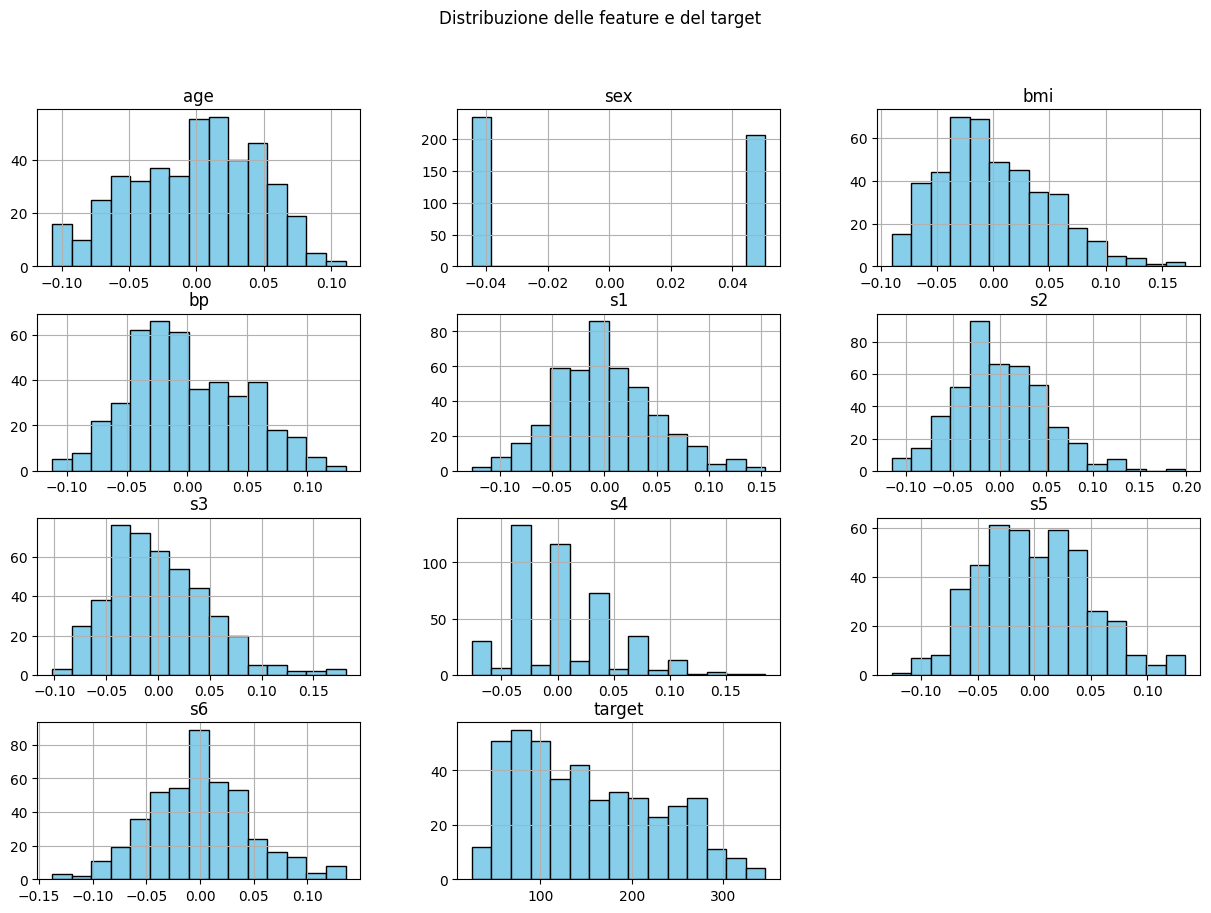

In [37]:
df.hist(bins=15, figsize=(15,10), color='skyblue', edgecolor='black')
plt.suptitle("Distribuzione delle feature e del target")
plt.show()

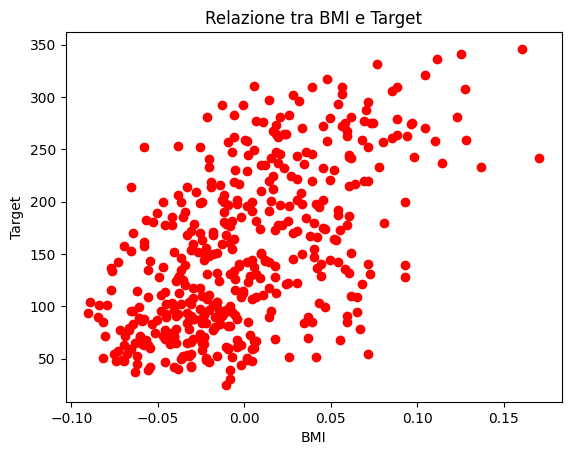

In [38]:
plt.scatter(df['bmi'], df['target'], color='red')
plt.title('Relazione tra BMI e Target')
plt.xlabel('BMI')
plt.ylabel('Target')
plt.show()

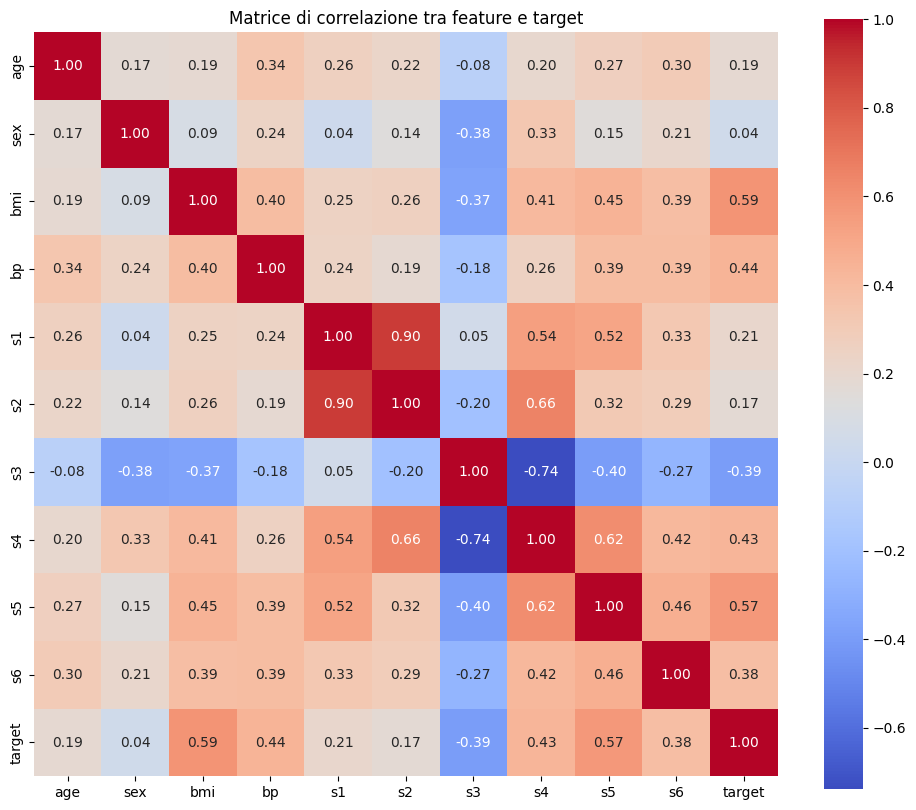

In [39]:
plt.figure(figsize=(12,10))
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True)
plt.title("Matrice di correlazione tra feature e target")
plt.show()

In [40]:
X = df[['bmi']].values
y = df['target'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [41]:
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [42]:
print(f"Coefficiente: {model.coef_[0]:.4f}, Intercetta: {model.intercept_:.2f}")
print(f"MSE: {mean_squared_error(y_test, y_pred):.2f}")
print(f"R²: {r2_score(y_test, y_pred):.2f}")

Coefficiente: 998.5777, Intercetta: 152.00
MSE: 4061.83
R²: 0.23


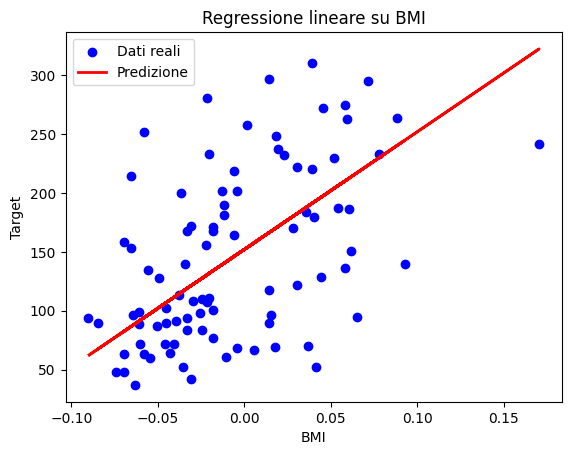

In [43]:
plt.scatter(X_test, y_test, color='blue', label='Dati reali')
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Predizione')
plt.title('Regressione lineare su BMI')
plt.xlabel('BMI')
plt.ylabel('Target')
plt.legend()
plt.show()

In [44]:
relevant_features = corr_matrix['target'].abs().sort_values(ascending=False)
relevant_features = relevant_features[relevant_features > 0.3].index.tolist()
relevant_features.remove('target')
print("Feature selezionate:", relevant_features)

Feature selezionate: ['bmi', 's5', 'bp', 's4', 's3', 's6']


In [45]:
X_best = df[relevant_features].values
X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(X_best, y, test_size=0.2, random_state=42)

In [46]:
model_best = LinearRegression()
model_best.fit(X_train_b, y_train_b)
y_pred_m = model_best.predict(X_test_b)

In [47]:
print(f"Coefficiente: {model_best.coef_[0]:.4f}, Intercetta: {model_best.intercept_:.2f}")
print(f"MSE: {mean_squared_error(y_test_b, y_pred_m):.2f}")
print(f"R²: {r2_score(y_test_b, y_pred_m):.2f}")

Coefficiente: 596.8094, Intercetta: 151.45
MSE: 2931.04
R²: 0.45


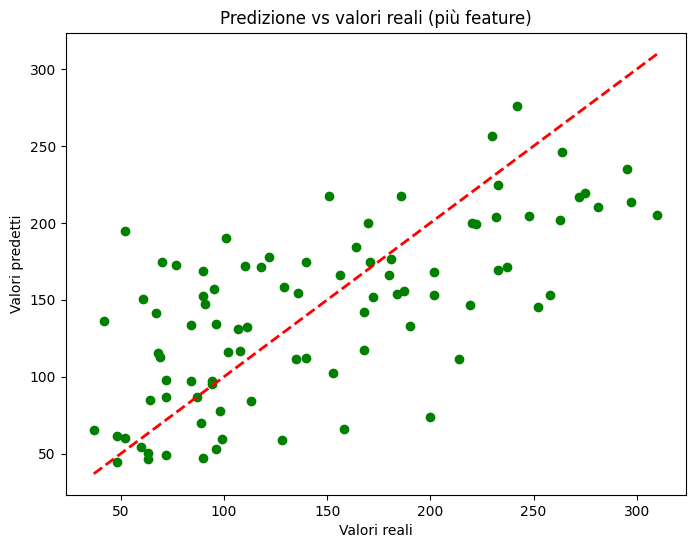

In [48]:
plt.figure(figsize=(8,6))
plt.scatter(y_test_b, y_pred_m, color='green')
plt.plot([y_test_b.min(), y_test_b.max()],
         [y_test_b.min(), y_test_b.max()], 'r--', lw=2)
plt.xlabel('Valori reali')
plt.ylabel('Valori predetti')
plt.title('Predizione vs valori reali (più feature)')
plt.show()